In [10]:
# 1. Instalamos las librerías necesarias
!pip install -q getdist emcee

import numpy as np
import pandas as pd
import scipy.integrate as integrate
import matplotlib.pyplot as plt

print("Cargando los datos...")

# 2. Cargar el "CSV" engañoso con Pandas
nombres_columnas = ['PREFIX', 'CID', 'IDSURVEY', 'zHD', 'zHEL', 'MU', 'MUERR', 'MUERR_VPEC', 'MUERR_SYS', 'PROB1A_BEAMS']

df_des = pd.read_csv('DES-Dovekie_HD.csv',
                     sep=r'\s+',
                     comment='#',
                     names=nombres_columnas
                    )

# Forzamos que las columnas sean números decimales (floats)
df_des['zHD'] = pd.to_numeric(df_des['zHD'], errors='coerce')
df_des['MU'] = pd.to_numeric(df_des['MU'], errors='coerce')

# Borramos las filas vacías
df_des = df_des.dropna(subset=['zHD', 'MU'])

z_obs = df_des['zHD'].values.astype(float)
mu_obs = df_des['MU'].values.astype(float)

# 3. Cargar la Matriz de Covarianza Inversa (.npz)
archivo_npz = np.load('STAT+SYS.npz')

nsn = int(np.squeeze(archivo_npz['nsn']))
inv_cov_cruda = archivo_npz['cov']

# --- EL DESENROLLADOR DEL TRIÁNGULO ---
# Verificamos si el tamaño coincide exactamente con el triángulo superior N*(N+1)/2
if len(inv_cov_cruda.shape) == 1 and len(inv_cov_cruda) == (nsn * (nsn + 1)) // 2:
    print(f"La matriz vino comprimida en triángulo. Reconstruyendo a {nsn}x{nsn}...")

    # 1. Creamos una matriz vacía de NxN
    inv_cov = np.zeros((nsn, nsn))

    # 2. Obtenemos las coordenadas (i, j) del triángulo superior
    i_upper, j_upper = np.triu_indices(nsn)

    # 3. Llenamos el triángulo superior con los datos crudos
    inv_cov[i_upper, j_upper] = inv_cov_cruda

    # 4. Hacemos que sea simétrica copiando lo de arriba hacia abajo
    i_lower, j_lower = np.tril_indices(nsn, -1)
    inv_cov[i_lower, j_lower] = inv_cov.T[i_lower, j_lower]

else:
    # Por si acaso la descargaste en otro formato que ya venía en 2D
    inv_cov = inv_cov_cruda.reshape((nsn, nsn))


print(f"\n¡Éxito! Se cargaron {len(z_obs)} supernovas perfectamente numéricas.")
print(f"Tamaño real de la matriz de covarianza inversa: {inv_cov.shape}")

Cargando los datos...
La matriz vino comprimida en triángulo. Reconstruyendo a 1820x1820...

¡Éxito! Se cargaron 1820 supernovas perfectamente numéricas.
Tamaño real de la matriz de covarianza inversa: (1820, 1820)


In [11]:
import emcee

# ---------------------------------------------------------
# 1. EL MODELO FÍSICO (Universo Flat Lambda-CDM)
# ---------------------------------------------------------
def E_z(z, Om):
    return np.sqrt(Om * (1 + z)**3 + (1 - Om))

def distancia_luminosidad(z_array, Om, H0):
    c = 299792.458 # km/s
    # Integramos para cada supernova en el arreglo
    ints = np.array([integrate.quad(lambda x: 1.0/E_z(x, Om), 0, zi)[0] for zi in z_array])
    return (c / H0) * (1 + z_array) * ints

def mu_teoria(z_array, Om, H0, M_offset):
    D_L = distancia_luminosidad(z_array, Om, H0)
    return 5 * np.log10(D_L * 1e5) + M_offset

# ---------------------------------------------------------
# 2. LA FUNCIÓN LIKELIHOOD (Chi-cuadrado)
# ---------------------------------------------------------
def log_likelihood(theta, z, mu_obs, inv_cov):
    Om, H0, M_offset = theta
    mu_th = mu_teoria(z, Om, H0, M_offset)
    delta_mu = mu_obs - mu_th
    # Multiplicación matricial: delta^T * C^-1 * delta
    chi2 = np.dot(delta_mu.T, np.dot(inv_cov, delta_mu))
    return -0.5 * chi2

# ---------------------------------------------------------
# 3. LOS PRIORS (¡Aquí entra SH0ES!)
# ---------------------------------------------------------
def log_prior(theta):
    Om, H0, M_offset = theta

    # Límites lógicos para que el código no colapse
    if not (0.0 < Om < 1.0 and 50.0 < H0 < 100.0 and -5.0 < M_offset < 5.0):
        return -np.inf

    # PRIOR DE SH0ES: Obligamos al H0 a estar anclado a la física local
    # (H0 = 73.04 +- 1.04 de Riess et al. 2022)
    chi2_SH0ES = ((H0 - 73.04) / 1.04)**2

    return -0.5 * chi2_SH0ES

def log_probability(theta, z, mu_obs, inv_cov):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, mu_obs, inv_cov)

# ---------------------------------------------------------
# 4. EJECUTAR LA CADENA DE MARKOV (MCMC)
# ---------------------------------------------------------
n_walkers = 16
n_dim = 3  # [Omega_m, H0, M_offset]
n_steps = 1500 # Un número razonable para termalizar

# Iniciamos los caminadores cerca de los valores esperados
pos_inicial = [0.33, 73.0, 0.0] + 1e-4 * np.random.randn(n_walkers, n_dim)

sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_probability, args=(z_obs, mu_obs, inv_cov))

print(f"Iniciando MCMC de {n_steps} pasos...")
sampler.run_mcmc(pos_inicial, n_steps, progress=True)
print("¡Simulación completada!")

Iniciando MCMC de 1500 pasos...


100%|██████████| 1500/1500 [57:04<00:00,  2.28s/it]

¡Simulación completada!


Removed no burn in

--- Resultados Finales (DES + SH0ES) ---
H_0 = 73.1\pm 1.0
\Omega_m = 0.329\pm 0.015


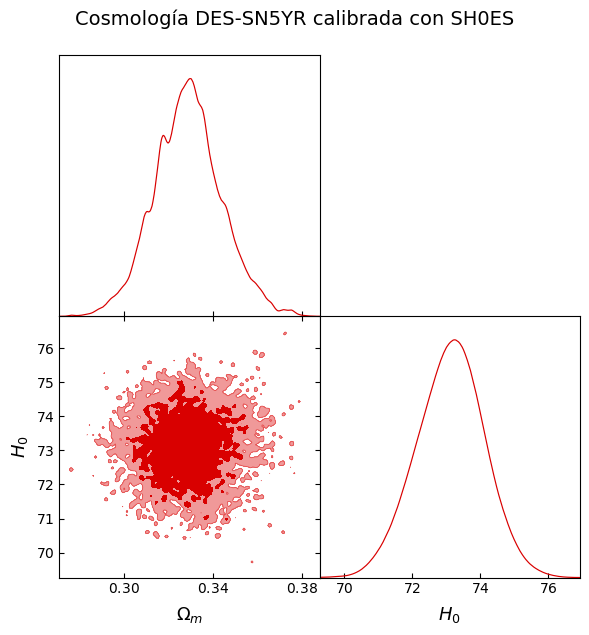


La tensión Q_DM frente a Planck es de: 5.13 sigmas


In [12]:
import getdist
from getdist import MCSamples, plots

# 1. Cortamos el primer 30% como "burn-in"
burn_in = int(0.3 * n_steps)
muestras_planas = sampler.get_chain(discard=burn_in, flat=True)

# 2. Pasamos los datos a GetDist (Columna 0 es Om, Columna 1 es H0)
muestras_para_getdist = np.column_stack((muestras_planas[:, 1], muestras_planas[:, 0]))

chain_des = MCSamples(samples=muestras_para_getdist,
                      names=['H0', 'omegam'],
                      labels=['H_0', r'\Omega_m'])

print("\n--- Resultados Finales (DES + SH0ES) ---")
print(chain_des.getInlineLatex('H0'))
print(chain_des.getInlineLatex('omegam'))

# 3. Graficar el resultado
g = plots.get_subplot_plotter(width_inch=6)
g.triangle_plot([chain_des], ['omegam', 'H0'],
                filled=True, contour_colors=["#D90000"])

plt.suptitle('Cosmología DES-SN5YR calibrada con SH0ES', fontsize=14, y=1.05)
plt.show()

# 4. Cálculo de tu métrica Q_DM frente a Planck (H0 = 67.4 +- 0.5)
H0_des_mean = chain_des.getMeans()[0]
H0_des_var = chain_des.getVars()[0]

Q_DM = ((H0_des_mean - 67.4)**2) / (H0_des_var + 0.5**2)
tension_sigmas = np.sqrt(Q_DM)

print(f"\nLa tensión Q_DM frente a Planck es de: {tension_sigmas:.2f} sigmas")

In [13]:
# Guardamos la cadena en un archivo .txt separado por espacios
# 'header' añade los nombres de las variables en la primera línea
np.savetxt('cadena_des_shoes.txt', muestras_planas,
           header='Om H0 M_offset', comments='')

print("¡Cadena guardada exitosamente como cadena_des_shoes.txt!")

# Para volver a cargarlo en el futuro:
# muestras_recuperadas = np.loadtxt('cadena_des_shoes.txt', skiprows=1)

¡Cadena guardada exitosamente como cadena_des_shoes.txt!


In [14]:
import datetime

print("Preparando los datos y el encabezado...")

# 1. Extraemos el log-posterior (post) directamente del sampler
post_plano = sampler.get_log_prob(discard=burn_in, flat=True)

# 2. Recalculamos el log-prior para cada muestra usando tu función log_prior
# (Como son muchas muestras, esto puede tardar un par de segundos)
prior_plano = np.array([log_prior(theta) for theta in muestras_planas])

# 3. Unimos las 3 columnas de parámetros con las 2 de probabilidades
# El orden será: Om, H0, M_offset, prior, post
datos_completos = np.column_stack((muestras_planas, prior_plano, post_plano))

# 4. Construimos el encabezado personalizado
# Usamos f-strings para inyectar variables reales de tu simulación
fecha_actual = datetime.datetime.now().isoformat()
muestras_totales = len(muestras_planas)

encabezado_cosmosis = f"""cosmological_parameters--omega_m	cosmological_parameters--h0	supernova_params--m	prior	post
#sampler=emcee
#n_varied=3
#timestamp={fecha_actual}
#walkers={n_walkers}
#samples={muestras_totales}
#nsteps={n_steps}
## START_OF_PARAMS_INI
## [runtime]
## sampler = emcee
## likelihood_only = T
##
## [emcee]
## walkers = {n_walkers}
## samples = {muestras_totales}
## nsteps = {n_steps}
##
## [pipeline]
## modules = consistency camb pantheon
## likelihoods = pantheon
## END_OF_PARAMS_INI
## START_OF_VALUES_INI
## [cosmological_parameters]
## omega_m = 0.0  0.33  1.0
## h0 = 50.0  73.0  100.0
##
## [supernova_params]
## m = -5.0  0.0  5.0
## END_OF_VALUES_INI
## START_OF_PRIORS_INI
## [cosmological_parameters]
## h0 = gaussian 73.04 1.04
## END_OF_PRIORS_INI"""

# 5. Guardamos el archivo
# comments='' evita que NumPy ponga un '#' extra al principio del texto
np.savetxt('cadena_des_shoes_cosmosis.txt',
           datos_completos,
           delimiter='\t',
           header=encabezado_cosmosis,
           comments='')

print("¡Listo! Cadena guardada exitosamente como 'cadena_des_shoes_cosmosis.txt'")

Preparando los datos y el encabezado...
¡Listo! Cadena guardada exitosamente como 'cadena_des_shoes_cosmosis.txt'


#Consideramos Union 3

In [18]:
!pip install -q astropy getdist emcee

import numpy as np
import emcee
from astropy.io import fits
import datetime
import getdist
from getdist import MCSamples, plots
import matplotlib.pyplot as plt

print("Cargando la matriz de Union3 desde el archivo FITS...")

# Leemos el archivo FITS (asegúrate de que esté subido a Colab)
archivo_fits = 'mu_mat_union3_cosmo=2_mu.fits'
hdul = fits.open(archivo_fits)
datos_fits = hdul[0].data

# La estructura de Rubin:
# Fila 0 (a partir de la columna 1) = redshift (z)
# Columna 0 (a partir de la fila 1) = módulo de distancia (mu)
# El bloque central = Matriz de covarianza inversa
z_obs_u3 = datos_fits[0, 1:]
mu_obs_u3 = datos_fits[1:, 0]
inv_cov_u3 = datos_fits[1:, 1:]

hdul.close()

print(f"¡Éxito! Se cargaron {len(z_obs_u3)} supernovas de Union3.")
print(f"Tamaño de la matriz de covarianza inversa: {inv_cov_u3.shape}")

Cargando la matriz de Union3 desde el archivo FITS...
¡Éxito! Se cargaron 22 supernovas de Union3.
Tamaño de la matriz de covarianza inversa: (22, 22)


In [19]:
# Configuración del MCMC
n_walkers = 16
n_dim = 3  # [Omega_m, H0, M_offset]
n_steps = 1500

# Iniciamos los caminadores
pos_inicial = [0.33, 73.0, 0.0] + 1e-4 * np.random.randn(n_walkers, n_dim)

# Creamos el sampler con los datos de Union3
sampler_u3 = emcee.EnsembleSampler(n_walkers, n_dim, log_probability,
                                   args=(z_obs_u3, mu_obs_u3, inv_cov_u3))

print(f"Iniciando MCMC de Union3 + SH0ES ({n_steps} pasos)...")
sampler_u3.run_mcmc(pos_inicial, n_steps, progress=True)
print("¡Simulación completada!")

# Extraemos la cadena descartando el primer 30% como burn-in
burn_in = int(0.3 * n_steps)
muestras_planas_u3 = sampler_u3.get_chain(discard=burn_in, flat=True)
muestras_totales_u3 = len(muestras_planas_u3)

Iniciando MCMC de Union3 + SH0ES (1500 pasos)...


100%|██████████| 1500/1500 [00:37<00:00, 40.41it/s]

¡Simulación completada!


Generando gráfico de contornos...
Removed no burn in

--- Resultados Union3 + SH0ES ---
H_0 = 73.04\pm 0.99
\Omega_m = 0.356\pm 0.027


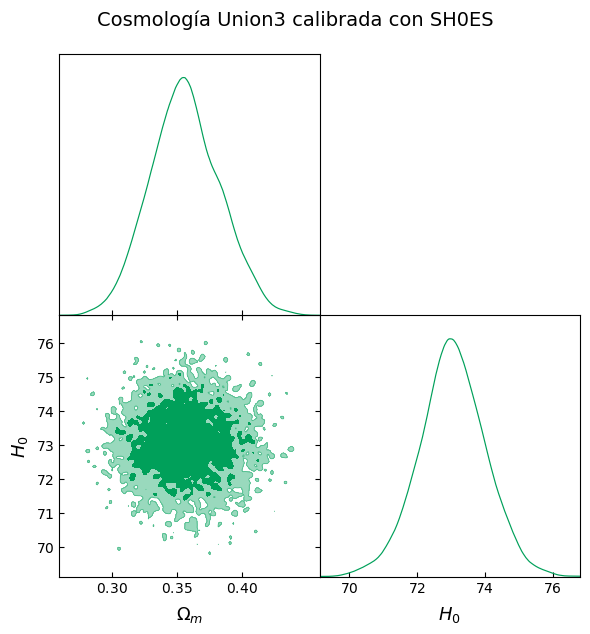

In [20]:
print("Generando gráfico de contornos...")

# Extraemos las columnas en el orden correcto para GetDist (H0, omegam)
col_omegam_u3 = muestras_planas_u3[:, 0]
col_H0_u3 = muestras_planas_u3[:, 1]
muestras_getdist_u3 = np.column_stack((col_H0_u3, col_omegam_u3))

# Creamos el objeto de muestras
chain_u3 = MCSamples(samples=muestras_getdist_u3,
                     names=['H0', 'omegam'],
                     labels=['H_0', r'\Omega_m'],
                     name_tag='Union3')

# Resultados rápidos en texto
print("\n--- Resultados Union3 + SH0ES ---")
print(chain_u3.getInlineLatex('H0'))
print(chain_u3.getInlineLatex('omegam'))

# Graficamos el triángulo
g = plots.get_subplot_plotter(width_inch=6)
g.triangle_plot([chain_u3], ['omegam', 'H0'],
                filled=True, contour_colors=["#00A05A"])

plt.suptitle('Cosmología Union3 calibrada con SH0ES', fontsize=14, y=1.05)
plt.show()

In [21]:
print("Guardando las cadenas...")

# ---------------------------------------------------------
# 1. GUARDAR COMO .TXT SIMPLE
# ---------------------------------------------------------
np.savetxt('cadena_union3_shoes.txt', muestras_planas_u3,
           header='Om H0 M_offset', comments='')
print("- Archivo 'cadena_union3_shoes.txt' generado.")

# ---------------------------------------------------------
# 2. GUARDAR COMO .TXT FORMATO COSMOSIS
# ---------------------------------------------------------
# Extraemos el posterior
post_plano_u3 = sampler_u3.get_log_prob(discard=burn_in, flat=True)

# Recalculamos el prior para cada muestra (puede tardar unos segundos)
prior_plano_u3 = np.array([log_prior(theta) for theta in muestras_planas_u3])

# Unimos todo: Om, H0, M_offset, prior, post
datos_cosmosis_u3 = np.column_stack((muestras_planas_u3, prior_plano_u3, post_plano_u3))

fecha_actual = datetime.datetime.now().isoformat()

encabezado_cosmosis_u3 = f"""cosmological_parameters--omega_m	cosmological_parameters--h0	supernova_params--m	prior	post
#sampler=emcee
#n_varied=3
#timestamp={fecha_actual}
#walkers={n_walkers}
#samples={muestras_totales_u3}
#nsteps={n_steps}
## START_OF_PARAMS_INI
## [runtime]
## sampler = emcee
## likelihood_only = T
##
## [emcee]
## walkers = {n_walkers}
## samples = {muestras_totales_u3}
## nsteps = {n_steps}
##
## [pipeline]
## modules = consistency camb pantheon
## likelihoods = pantheon
## END_OF_PARAMS_INI
## START_OF_VALUES_INI
## [cosmological_parameters]
## omega_m = 0.0  0.33  1.0
## h0 = 50.0  73.0  100.0
##
## [supernova_params]
## m = -5.0  0.0  5.0
## END_OF_VALUES_INI
## START_OF_PRIORS_INI
## [cosmological_parameters]
## h0 = gaussian 73.04 1.04
## END_OF_PRIORS_INI"""

np.savetxt('cadena_union3_shoes_cosmosis.txt',
           datos_cosmosis_u3,
           delimiter='\t',
           header=encabezado_cosmosis_u3,
           comments='')
print("- Archivo 'cadena_union3_shoes_cosmosis.txt' generado.")

Guardando las cadenas...
- Archivo 'cadena_union3_shoes.txt' generado.
- Archivo 'cadena_union3_shoes_cosmosis.txt' generado.


#Vamos a generar las mismas cadenas de antes pero cambiando el prior de H_0. En lugar de ~  73, a 67 [1/s]

In [ ]:
import emcee
import getdist
from getdist import MCSamples, plots
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. EL MODELO FÍSICO Y LIKELIHOOD (DES)
# ---------------------------------------------------------
def E_z(z, Om):
    return np.sqrt(Om * (1 + z)**3 + (1 - Om))

def distancia_luminosidad(z_array, Om, H0):
    c = 299792.458
    ints = np.array([integrate.quad(lambda x: 1.0/E_z(x, Om), 0, zi)[0] for zi in z_array])
    return (c / H0) * (1 + z_array) * ints

def mu_teoria(z_array, Om, H0, M_offset):
    D_L = distancia_luminosidad(z_array, Om, H0)
    return 5 * np.log10(D_L * 1e5) + M_offset

def log_likelihood(theta, z, mu_obs, inv_cov):
    Om, H0, M_offset = theta
    mu_th = mu_teoria(z, Om, H0, M_offset)
    delta_mu = mu_obs - mu_th
    return -0.5 * np.dot(delta_mu.T, np.dot(inv_cov, delta_mu))

# ---------------------------------------------------------
# 2. EL NUEVO PRIOR (¡AQUÍ ENTRA PLANCK!)
# ---------------------------------------------------------
def log_prior_planck(theta):
    Om, H0, M_offset = theta
    if not (0.0 < Om < 1.0 and 50.0 < H0 < 100.0 and -5.0 < M_offset < 5.0):
        return -np.inf

    chi2_Planck = ((H0 - 67.4) / 0.5)**2
    return -0.5 * chi2_Planck

def log_prob_planck(theta, z, mu_obs, inv_cov):
    lp = log_prior_planck(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, mu_obs, inv_cov)

# ---------------------------------------------------------
# 3. EJECUTAR EL MCMC (DES + PLANCK)
# ---------------------------------------------------------
n_walkers, n_dim, n_steps = 16, 3, 1500
pos_inicial = [0.33, 67.4, 0.0] + 1e-4 * np.random.randn(n_walkers, n_dim)

print("Iniciando MCMC para DES con prior de PLANCK...")
sampler_des_planck = emcee.EnsembleSampler(n_walkers, n_dim, log_prob_planck, args=(z_obs, mu_obs, inv_cov))
sampler_des_planck.run_mcmc(pos_inicial, n_steps, progress=True)

# ---------------------------------------------------------
# 4. EXTRACCIÓN Y GUARDADO EN ARCHIVO TEXTO (.TXT)
# ---------------------------------------------------------
muestras_des_p = sampler_des_planck.get_chain(discard=int(0.3*n_steps), flat=True)

# Definimos el encabezado para que sepas qué es cada columna al abrir el bloc de notas
encabezado_des = "Omega_m\tH0\tM_offset"

np.savetxt('cadena_des_planck.txt',
           muestras_des_p,
           delimiter='\t',
           header=encabezado_des,
           comments='')

print("- Archivo 'cadena_des_planck.txt' generado y guardado exitosamente.")

# ---------------------------------------------------------
# 5. ANÁLISIS CON GETDIST Y GRÁFICO
# ---------------------------------------------------------
muestras_gd_des_p = np.column_stack((muestras_des_p[:, 1], muestras_des_p[:, 0]))
chain_des_p = MCSamples(samples=muestras_gd_des_p, names=['H0', 'omegam'], labels=['H_0', r'\Omega_m'])

print("\n--- Resultados Finales (DES + PLANCK) ---")
print(chain_des_p.getInlineLatex('H0'))
print(chain_des_p.getInlineLatex('omegam'))

g = plots.get_subplot_plotter(width_inch=6)
g.triangle_plot([chain_des_p], ['omegam', 'H0'], filled=True, contour_colors=["#0055A4"])
plt.suptitle('Cosmología DES-SN5YR calibrada con PLANCK', fontsize=14, y=1.05)
plt.show()

# Cálculo de Tensión inversa (Contra SH0ES: 73.04 +- 1.04)
H0_mean, H0_var = chain_des_p.getMeans()[0], chain_des_p.getVars()[0]
tension_sigmas = np.sqrt(((H0_mean - 73.04)**2) / (H0_var + 1.04**2))
print(f"\nLa tensión frente a SH0ES local es de: {tension_sigmas:.2f} sigmas")

Iniciando MCMC para DES con prior de PLANCK...


 54%|█████▎    | 804/1500 [30:34<24:58,  2.15s/it]

Iniciando MCMC para Union3 con prior de PLANCK...


100%|██████████| 1500/1500 [00:27<00:00, 53.59it/s]


- Archivo 'cadena_union3_planck.txt' generado y guardado exitosamente.
Removed no burn in

--- Resultados Finales (UNION3 + PLANCK) ---
H_0 = 67.38\pm 0.49
\Omega_m = 0.357\pm 0.027


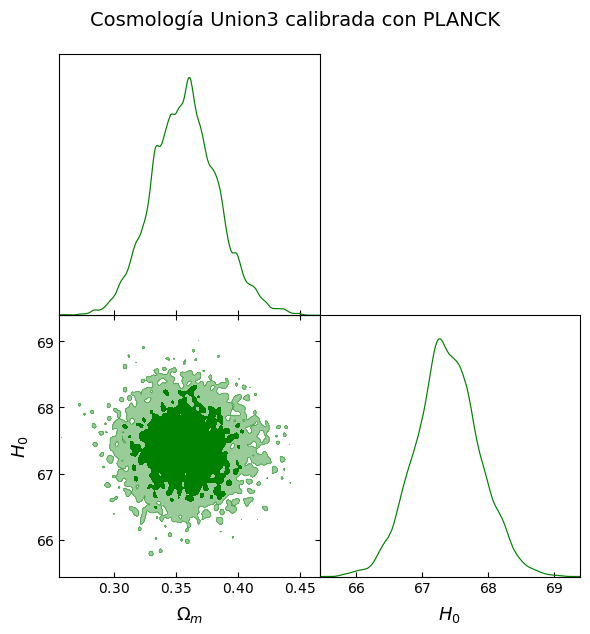


La tensión de Union3 frente a SH0ES local es de: 4.92 sigmas


In [24]:
# ---------------------------------------------------------
# 1. EJECUTAR EL MCMC (UNION3 + PLANCK)
# ---------------------------------------------------------
n_walkers, n_dim, n_steps = 16, 3, 1500
pos_inicial_u3 = [0.33, 67.4, 0.0] + 1e-4 * np.random.randn(n_walkers, n_dim)

print("Iniciando MCMC para Union3 con prior de PLANCK...")
sampler_u3_planck = emcee.EnsembleSampler(n_walkers, n_dim, log_prob_planck, args=(z_obs_u3, mu_obs_u3, inv_cov_u3))
sampler_u3_planck.run_mcmc(pos_inicial_u3, n_steps, progress=True)

# ---------------------------------------------------------
# 2. EXTRACCIÓN Y GUARDADO EN ARCHIVO TEXTO (.TXT)
# ---------------------------------------------------------
muestras_u3_p = sampler_u3_planck.get_chain(discard=int(0.3*n_steps), flat=True)

encabezado_u3 = "Omega_m\tH0\tM_offset"

np.savetxt('cadena_union3_planck.txt',
           muestras_u3_p,
           delimiter='\t',
           header=encabezado_u3,
           comments='')

print("- Archivo 'cadena_union3_planck.txt' generado y guardado exitosamente.")

# ---------------------------------------------------------
# 3. ANÁLISIS CON GETDIST Y GRÁFICO
# ---------------------------------------------------------
muestras_gd_u3_p = np.column_stack((muestras_u3_p[:, 1], muestras_u3_p[:, 0]))
chain_u3_p = MCSamples(samples=muestras_gd_u3_p, names=['H0', 'omegam'], labels=['H_0', r'\Omega_m'])

print("\n--- Resultados Finales (UNION3 + PLANCK) ---")
print(chain_u3_p.getInlineLatex('H0'))
print(chain_u3_p.getInlineLatex('omegam'))

g = plots.get_subplot_plotter(width_inch=6)
g.triangle_plot([chain_u3_p], ['omegam', 'H0'], filled=True, contour_colors=["#008000"])
plt.suptitle('Cosmología Union3 calibrada con PLANCK', fontsize=14, y=1.05)
plt.show()

# Cálculo de Tensión inversa (Contra SH0ES: 73.04 +- 1.04)
H0_mean_u3, H0_var_u3 = chain_u3_p.getMeans()[0], chain_u3_p.getVars()[0]
tension_sigmas_u3 = np.sqrt(((H0_mean_u3 - 73.04)**2) / (H0_var_u3 + 1.04**2))
print(f"\nLa tensión de Union3 frente a SH0ES local es de: {tension_sigmas_u3:.2f} sigmas")